# Proyek Analisis Data: [bike Sharing Dataset]
- **Nama:** Anwar Ibrahim
- **Email:** cdcc229d6y1387@student.devacademy.id
- **ID Dicoding:** CDCC229D6Y1387

## Menentukan Pertanyaan Bisnis

- Bagaimana perbandingan rata-rata jumlah penyewaan sepeda harian (cnt) antara hari kerja (workingday) dan hari libur (holiday) selama periode tahun 2011–2012?
- Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda harian (cnt) selama periode tahun 2011–2012, dan kondisi cuaca mana yang menghasilkan penyewaan tertinggi?

## Import Semua Packages/Library yang Digunakan

In [33]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns


- Pada tahap ini saya memanggil library numpy, pandas, scipy, matplotlib, seaborn untuk melakukan data analisis

## Data Wrangling

### Gathering Data

In [34]:
day_df= pd.read_csv('Data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Pada proses Gathering data ini saya memuat data day_df menggunakan pandas, setelah itu saya menggunakan function head() untuk menampilkan 5 data

**Insight:**
- Memuat tabel day_df ke project
- menampilkan 5 data terawal pada tabel day_df

### Assessing Data

Menilai Data day_df

In [35]:
#Missing value day_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [36]:
#Cek Duplikasi
print("Jumlah duplikasi: ", day_df.duplicated().sum())
#Memunculkan
day_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Pada tahap Assesing data ini saya menggunakan function info() untuk mendapatkan info sepenuhnya dari data, mulai dari missing value sampai tipe data, selanutnya saya menggunakan duplicated() untuk mengecek apakah ada duplikasi data pada dataset saya, dan menggunakan function describe() untuk memunculkan statistika deskriptif

**Insight:**
- Pada data day_df bisa dilihat tidak ada missing value dan duplikasi, tetapi ada kesalahan pada tipedata dteday yang seharusnya tipe datanya adalah datetime bukan object.



### Cleaning Data

In [37]:
#Mengubah tipe data dteday
datetime_columns = ["dteday"]

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])

#Cek kembali tipe datanya apakah sudah berubah
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

pada data cleaning ini saya mengubah tipe data dteday dari object menjadi datetime, kemudian mengecek kembali apakah tipe data secara keseluruhan menggunakan function info()

**Insight:**
- Setelah melakukan cleaning data, pada tabel day_df tipe data dteday sudah berubah menjadi datetime

## Exploratory Data Analysis (EDA)

### Explore ...


Ekspslorasi data day_df

In [38]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [39]:
workingday_vs_holiday = day_df.groupby("workingday")["cnt"].mean().reset_index()
workingday_vs_holiday["workingday"] = workingday_vs_holiday["workingday"].map({
    0: "Holiday",
    1: "Working Day"
})
print(workingday_vs_holiday)

    workingday          cnt
0      Holiday  4330.168831
1  Working Day  4584.820000


In [40]:
#Melakukan kategorikal encoding pada fitur cuaca supaya lebih mudah dibaca semua orang
analisis_cuaca = day_df.groupby("weathersit")["cnt"].mean().reset_index()

analisis_cuaca["weathersit"] = analisis_cuaca["weathersit"].map({
    1: "Cerah",
    2: "Mendung",
    3: "Hujan Ringan"
})
print(analisis_cuaca)

     weathersit          cnt
0         Cerah  4876.786177
1       Mendung  4035.862348
2  Hujan Ringan  1803.285714


Pada sesi EDA ini saya menggunakan function describe(include=all) untuk menampilkan semua statistika deskriptif dari dataset saya, selanjutnya saya menggunakan groupby untuk mengelompokkan beberapa fitur yang saya punya.

**Insight:**
- dari tabel day_df yang saya eksplor saya mendapatkan bahwa orang yang menyewakan sepeda pada hari kerja pada periode 2011-2012 lebih banyak daripada ketika hari libur dengan total rata-rata penyewaan 4330 pada hari libur dan 4584 pada hari kerja. Perbedaannya tidak terlalu signifikan.
- dari tabel day_df yang saya eksplor saya menemukan bahwa rata-rata terjadinya penyewaan sepeda terjadi pada kondisi cuaca cerah (weathersit = 1) dengan rata-rata 4876 penyewa, kemudian diikuti kondisi mendung (weathersit = 2) dengan rata-rata 4035, dan yang paling rendah pada kondisi hujan ringan (weathersit = 3) dengan rata-rata 1803 penyewa. Ini menunjukkan bahwa pada tahun 2011-2012 cuaca memiliki pengaruh signifikan pada penyewaan sepeda. semakin baik kondisi cuacanya semakin tinggi penyewaan sepedanya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan rata-rata jumlah penyewaan sepeda harian (cnt) antara hari kerja (workingday) dan hari libur (holiday) selama periode tahun 2011–2012?

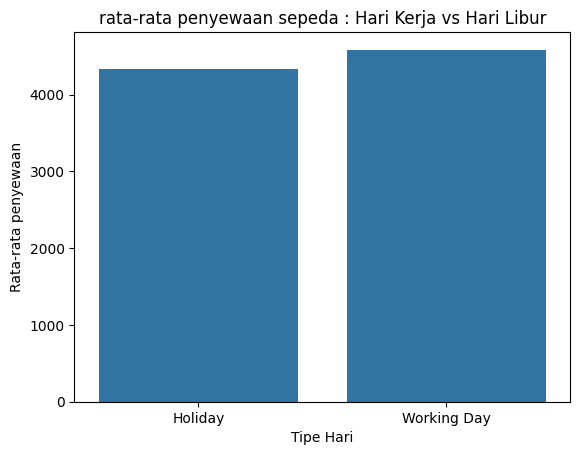

In [41]:
sns.barplot(x='workingday', y='cnt', data=workingday_vs_holiday)
plt.title('rata-rata penyewaan sepeda : Hari Kerja vs Hari Libur')
plt.xlabel('Tipe Hari')
plt.ylabel('Rata-rata penyewaan')
plt.show()



### Pertanyaan 2: Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda harian (cnt) selama periode tahun 2011–2012, dan kondisi cuaca mana yang menghasilkan penyewaan tertinggi?

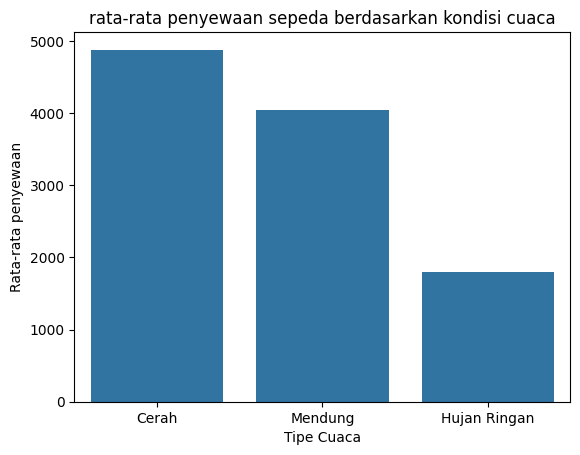

In [42]:
sns.barplot(x='weathersit', y='cnt', data=analisis_cuaca)
plt.title('rata-rata penyewaan sepeda berdasarkan kondisi cuaca')
plt.xlabel('Tipe Cuaca')
plt.ylabel('Rata-rata penyewaan')
plt.show()

Pada bagian visualisasi ini saya menggunakan barplot untuk melihat perbandingan pada pertanyaan 1 dan 2

**Insight:**
- Jadi, dari visualisasi data pada pertanyaan 1 kita bisa melihat bahwa penyewaan sepeda pada hari kerja lebih banyak dari pada hari libur, meskipun tidak terlalu signifikan perbedaan penyewaannya.
- Jadi, dari visualisasi data pertanyaan 2 kita bisa melihat jelas bahwa penyewaan sepeda paling banyak terjadi ketika cuacanya cerah (weathersit = 1), kemudian yang apling tinggi kedua yaitu ketika cuaca mendung (weathersit = 2) dan paling rendah ketika cuaca hujan ringan (weathersit = 3)

## Analisis Lanjutan (Opsional)

In [43]:
day_df["rental_level"] = pd.qcut(
    day_df["cnt"],
    q=3,
    labels=["Rendah", "Sedang", "Tinggi"]
)

day_df["rental_level"].value_counts()

,count
rental_level,
Rendah,244
Sedang,244
Tinggi,243


Pada analisis lanjutan ini saya menggunakan binning untuk mengkategorikan total penyewaan ke kategori rendah, sedang dan tinggi

## Conclusion

- Conclution pertanyaan 1 : Berdasarkan hasil analisis, rata-rata jumlah penyewaan sepeda pada hari kerja sedikit lebih tinggi dibandingkan hari libur selama periode 2011–2012. Namun, perbedaan tersebut tidak terlalu signifikan. Hal ini menunjukkan bahwa sepeda tidak hanya digunakan untuk aktivitas commuting pada hari kerja, tetapi juga cukup banyak digunakan untuk aktivitas rekreasi pada hari libur. Oleh karena itu penyedia harus tetap mempertahankan kesediaan sepeda baik di hari kerja maupun hari libur.
- Conclution pertanyaan 2 : Berdasarkan analisis kondisi cuaca, jumlah penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah dan menurun pada kondisi mendung serta hujan ringan. Hal ini menunjukkan bahwa cuaca memiliki pengaruh signifikan terhadap minat pengguna dalam menyewa sepeda. Dari analisis ini , penyedia dapat menyesuaikan strategi operasional dengan menambah jumlah sepeda saat cuaca cerah serta memberikan promo ketika kondisi cuaca kurang baik untuk meningkatkan jumlah penyewa ketika cuaca kurang baik
